連続時間信号 $x_e(t) = e^{j 6 \pi t}, x_{\mathrm{cos}}(t) = \cos(6 \pi t), x_{\mathrm{sin}}(t) = \sin(6 \pi t)$ を
サンプリング周波数 $F_s = 8$ Hz で標本化した信号をそれぞれ $x_e[n], x_{\mathrm{cos}}[n], x_{\mathrm{sin}}[n]$ とする．
これらの信号の8点 DFT を計算し，振幅スペクトルと位相スペクトルを描きなさい．
また，これらの信号の振幅スペクトルと位相スペクトルを比較し，どのような関係があるか考察しなさい

$$
e^{j6\pi t} = e^{j2\pi \cdot 3t}
$$

なので，周波数は $3\ \mathrm{Hz}$．

$F_s=8,\ N=8$ より，

$$
k
=
\frac{FN}{F_s}
=
\frac{3 \cdot 8}{8}
=
3
$$

**結果**

| 信号 | 非零ピーク | 振幅 | 位相 |
|---|---:|---:|---:|
| $e^{j6\pi t}$ | $k=3$ | $8$ | $0$ |
| $\cos(6\pi t)$ | $k=3,5$ | $4,4$ | $0,0$ |
| $\sin(6\pi t)$ | $k=3,5$ | $4,4$ | $-\pi/2,\ \pi/2$ |

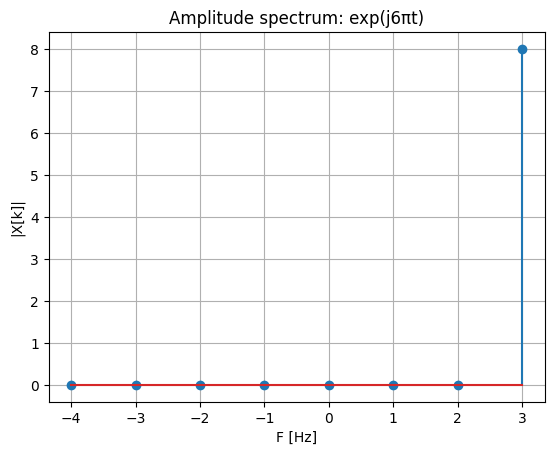

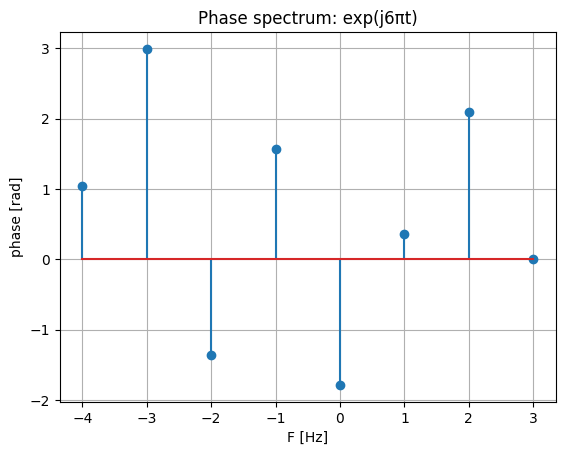

exp(j6πt)
k = 3 F = 3.0 amp = 8.0 phase = -2.9478201077245473e-16


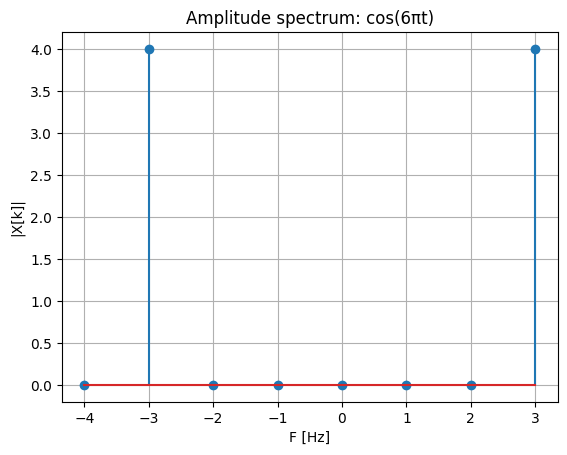

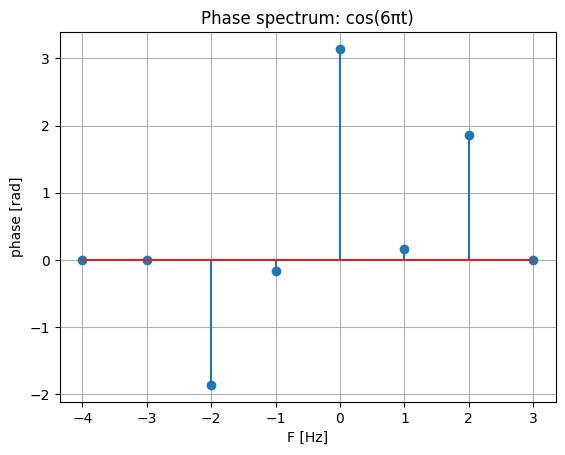

cos(6πt)
k = 3 F = 3.0 amp = 3.999999999999999 phase = -3.407062657404806e-16
k = 5 F = -3.0 amp = 3.999999999999999 phase = 3.407062657404806e-16


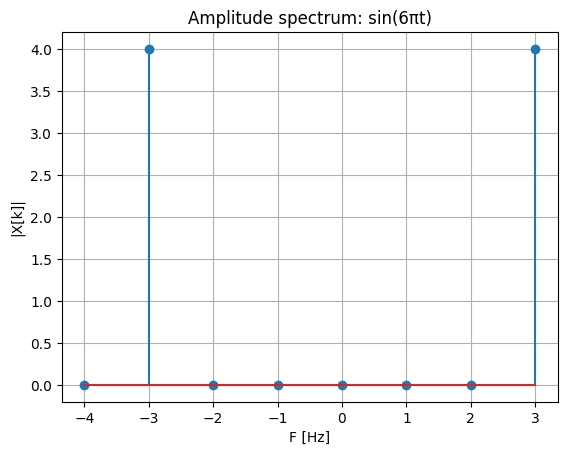

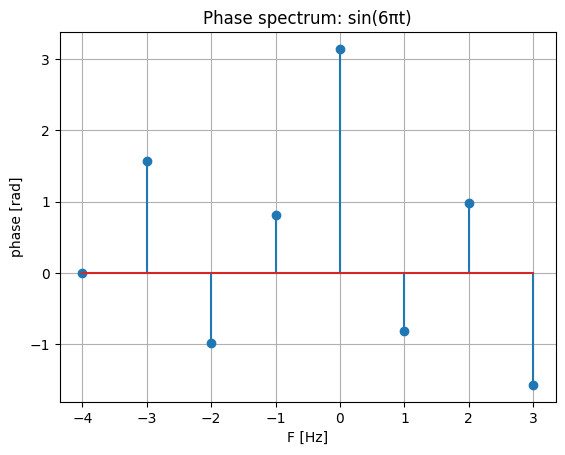

sin(6πt)
k = 3 F = 3.0 amp = 4.0 phase = -1.570796326794897
k = 5 F = -3.0 amp = 4.0 phase = 1.570796326794897


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 8
N = 8
n = np.arange(N)
t = n / Fs

signals = {
    "exp(j6πt)": np.exp(1j * 6 * np.pi * t),
    "cos(6πt)": np.cos(6 * np.pi * t),
    "sin(6πt)": np.sin(6 * np.pi * t),
}

F = np.fft.fftfreq(N, d=1/Fs)

for name, x in signals.items():
    X = np.fft.fft(x)
    amp = np.abs(X)
    phase = np.angle(X)

    plt.figure()
    plt.stem(F, amp)
    plt.xlabel("F [Hz]")
    plt.ylabel("|X[k]|")
    plt.title(f"Amplitude spectrum: {name}")
    plt.grid()
    plt.show()

    plt.figure()
    plt.stem(F, phase)
    plt.xlabel("F [Hz]")
    plt.ylabel("phase [rad]")
    plt.title(f"Phase spectrum: {name}")
    plt.grid()
    plt.show()

    print(name)
    for i in np.where(amp > 1e-8)[0]:
        print("k =", i, "F =", F[i], "amp =", amp[i], "phase =", phase[i])

- 複素指数 $e^{j6\pi t}$ は正周波数成分だけ
- 余弦波は正周波数と負周波数が同位相
- 正弦波は正周波数と負周波数が $\pm \pi/2$ だけずれる
- $\cos$ と $\sin$ は振幅スペクトルが同じで，位相スペクトルが異なる